Modelling Notebook
**Developed by** Maitan Yerassyl
**Dataset:** Diabetes Risk Prediction Dataset (Kaggle — vishardmehta)  
**Task type:** Multi-class Classification — predicting `diabetes_risk_category`  
**Models:** Logistic Regression (baseline) · Decision Tree · K-Nearest Neighbours (KNN)

---
## 0. Setup — Imports & Data Reconstruction
We re-run all preprocessing steps to reconstruct the `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` objects in this notebook's kernel.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

RISK_ORDER  = ['Low Risk', 'Prediabetes', 'High Risk']
RISK_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']

print('All libraries imported successfully.')

All libraries imported successfully.


In [4]:
# --- Reproduce Week 2 preprocessing ---
df = pd.read_csv('diabetes_risk_dataset.csv')

# Drop ID and leakage columns
df = df.drop(columns=['Patient_ID', 'diabetes_risk_score'])

# Feature engineering
df['glucose_bmi_interaction'] = df['fasting_glucose_level'] * df['bmi']

# Encode categorical features
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['physical_activity_level'] = df['physical_activity_level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
df['family_history_diabetes'] = df['family_history_diabetes'].map({'No': 0, 'Yes': 1})

# Encode target
target_order = {'Low Risk': 0, 'Prediabetes': 1, 'High Risk': 2}
df['diabetes_risk_category'] = df['diabetes_risk_category'].map(target_order)

# Split features / target
X = df.drop(columns=['diabetes_risk_category'])
y = df['diabetes_risk_category']

# Train / test split (stratified, same seed as Week 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale: fit on train only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print('Preprocessing complete.')
print(f'X_train: {X_train_scaled.shape}  |  X_test: {X_test_scaled.shape}')
print(f'y_train: {y_train.shape}          |  y_test:  {y_test.shape}')

Preprocessing complete.
X_train: (4800, 17)  |  X_test: (1200, 17)
y_train: (4800,)          |  y_test:  (1200,)


---
## 1. Baseline Model — Logistic Regression

Logistic Regression is the required linear baseline for all classification tasks in this course. As a linear model, it draws straight (hyperplane) decision boundaries in feature space. Given that our EDA showed strong linear separation between risk categories on glucose and HbA1c axes, Logistic Regression is expected to perform reasonably but may struggle with the interaction between features that tree-based models handle naturally.

We use `max_iter=1000` to ensure convergence on our 18-feature dataset and `random_state=42` for reproducibility.

In [5]:
# --- Train ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_lr = lr.predict(X_test_scaled)

# --- Evaluation ---
print('=' * 60)
print('MODEL 1: Logistic Regression (Baseline)')
print('=' * 60)
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Low Risk (0)', 'Prediabetes (1)', 'High Risk (2)']
))

MODEL 1: Logistic Regression (Baseline)
                 precision    recall  f1-score   support

   Low Risk (0)       0.96      0.96      0.96       520
Prediabetes (1)       0.85      0.85      0.85       231
  High Risk (2)       0.97      0.98      0.97       449

       accuracy                           0.94      1200
      macro avg       0.93      0.93      0.93      1200
   weighted avg       0.94      0.94      0.94      1200



In [6]:
# --- 5-Fold Cross-Validation ---
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('Logistic Regression — 5-Fold CV Results')
print(f'  CV Scores:  {np.round(cv_scores_lr, 4)}')
print(f'  Mean:       {cv_scores_lr.mean():.4f}')
print(f'  Std Dev:    {cv_scores_lr.std():.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')

Logistic Regression — 5-Fold CV Results
  CV Scores:  [0.9417 0.951  0.9604 0.9542 0.9406]
  Mean:       0.9496
  Std Dev:    0.0075
  Test Accuracy: 0.9433


---
## 2. Model 2 — Decision Tree Classifier

Decision Trees split the feature space using a series of threshold rules (e.g., `fasting_glucose_level > 126`). Unlike Logistic Regression, they can naturally model non-linear and interaction effects between features — exactly the kind of multi-feature thresholds that characterise clinical diabetes diagnosis. We use `max_depth=6` to prevent overfitting while allowing the tree to capture meaningful patterns beyond first-order splits. `class_weight='balanced'` is applied to address the Prediabetes class imbalance identified in Week 2 (19.2% of records).

In [7]:
# --- Train ---
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_dt = dt.predict(X_test_scaled)

# --- Evaluation ---
print('=' * 60)
print('MODEL 2: Decision Tree Classifier')
print('=' * 60)
print(classification_report(
    y_test, y_pred_dt,
    target_names=['Low Risk (0)', 'Prediabetes (1)', 'High Risk (2)']
))

MODEL 2: Decision Tree Classifier
                 precision    recall  f1-score   support

   Low Risk (0)       0.97      0.90      0.94       520
Prediabetes (1)       0.68      0.89      0.77       231
  High Risk (2)       0.97      0.90      0.93       449

       accuracy                           0.90      1200
      macro avg       0.87      0.90      0.88      1200
   weighted avg       0.92      0.90      0.90      1200



In [8]:
# --- 5-Fold Cross-Validation ---
cv_scores_dt = cross_val_score(dt, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('Decision Tree — 5-Fold CV Results')
print(f'  CV Scores:  {np.round(cv_scores_dt, 4)}')
print(f'  Mean:       {cv_scores_dt.mean():.4f}')
print(f'  Std Dev:    {cv_scores_dt.std():.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')

Decision Tree — 5-Fold CV Results
  CV Scores:  [0.8823 0.8927 0.8927 0.8917 0.8927]
  Mean:       0.8904
  Std Dev:    0.0041
  Test Accuracy: 0.8983


---
## 3. Model 3 — K-Nearest Neighbours (KNN)

KNN classifies each test point by majority vote among its `k` nearest neighbours in feature space. It makes no assumptions about the underlying data distribution (non-parametric), which can be beneficial when class boundaries are irregular. We use `k=11` — an odd number to avoid ties in multi-class voting, and large enough to smooth out noise while remaining sensitive to local structure. KNN is scale-sensitive, so the `StandardScaler` from Week 2 is essential here. One known weakness: KNN is computationally slow at prediction time and tends to struggle when irrelevant features add noise to the distance calculation.

In [9]:
# --- Train ---
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_knn = knn.predict(X_test_scaled)

# --- Evaluation ---
print('=' * 60)
print('MODEL 3: K-Nearest Neighbours (k=11)')
print('=' * 60)
print(classification_report(
    y_test, y_pred_knn,
    target_names=['Low Risk (0)', 'Prediabetes (1)', 'High Risk (2)']
))

MODEL 3: K-Nearest Neighbours (k=11)
                 precision    recall  f1-score   support

   Low Risk (0)       0.93      0.95      0.94       520
Prediabetes (1)       0.76      0.72      0.74       231
  High Risk (2)       0.94      0.94      0.94       449

       accuracy                           0.90      1200
      macro avg       0.87      0.87      0.87      1200
   weighted avg       0.90      0.90      0.90      1200



In [10]:
# --- 5-Fold Cross-Validation ---
cv_scores_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('KNN (k=11) — 5-Fold CV Results')
print(f'  CV Scores:  {np.round(cv_scores_knn, 4)}')
print(f'  Mean:       {cv_scores_knn.mean():.4f}')
print(f'  Std Dev:    {cv_scores_knn.std():.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')

KNN (k=11) — 5-Fold CV Results
  CV Scores:  [0.8812 0.8885 0.9    0.8938 0.8948]
  Mean:       0.8917
  Std Dev:    0.0064
  Test Accuracy: 0.9000


---
## 4. Model Comparison Table

All three models evaluated side-by-side on the same test set and 5-fold cross-validation split.

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect per-class and macro metrics for all models
models      = ['Logistic Regression', 'Decision Tree', 'KNN (k=11)']
preds       = [y_pred_lr, y_pred_dt, y_pred_knn]
cv_scores   = [cv_scores_lr, cv_scores_dt, cv_scores_knn]

rows = []
for name, y_pred, cv in zip(models, preds, cv_scores):
    rows.append({
        'Model'            : name,
        'Test Accuracy'    : round(accuracy_score(y_test, y_pred), 4),
        'Macro Precision'  : round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'Macro Recall'     : round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'Macro F1'         : round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'F1 — Low Risk'    : round(f1_score(y_test, y_pred, labels=[0], average='macro', zero_division=0), 4),
        'F1 — Prediabetes' : round(f1_score(y_test, y_pred, labels=[1], average='macro', zero_division=0), 4),
        'F1 — High Risk'   : round(f1_score(y_test, y_pred, labels=[2], average='macro', zero_division=0), 4),
        'CV Mean Acc'      : round(cv.mean(), 4),
        'CV Std'           : round(cv.std(), 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')

print('\n=== MODEL COMPARISON TABLE ===')
print(comparison_df.to_string())


=== MODEL COMPARISON TABLE ===
                     Test Accuracy  Macro Precision  Macro Recall  Macro F1  F1 — Low Risk  F1 — Prediabetes  F1 — High Risk  CV Mean Acc  CV Std
Model                                                                                                                                            
Logistic Regression         0.9433           0.9278        0.9280    0.9279         0.9576            0.8528          0.9733       0.9496  0.0075
Decision Tree               0.8983           0.8742        0.8965    0.8800         0.9360            0.7707          0.9332       0.8904  0.0041
KNN (k=11)                  0.9000           0.8741        0.8681    0.8709         0.9373            0.7378          0.9376       0.8917  0.0064


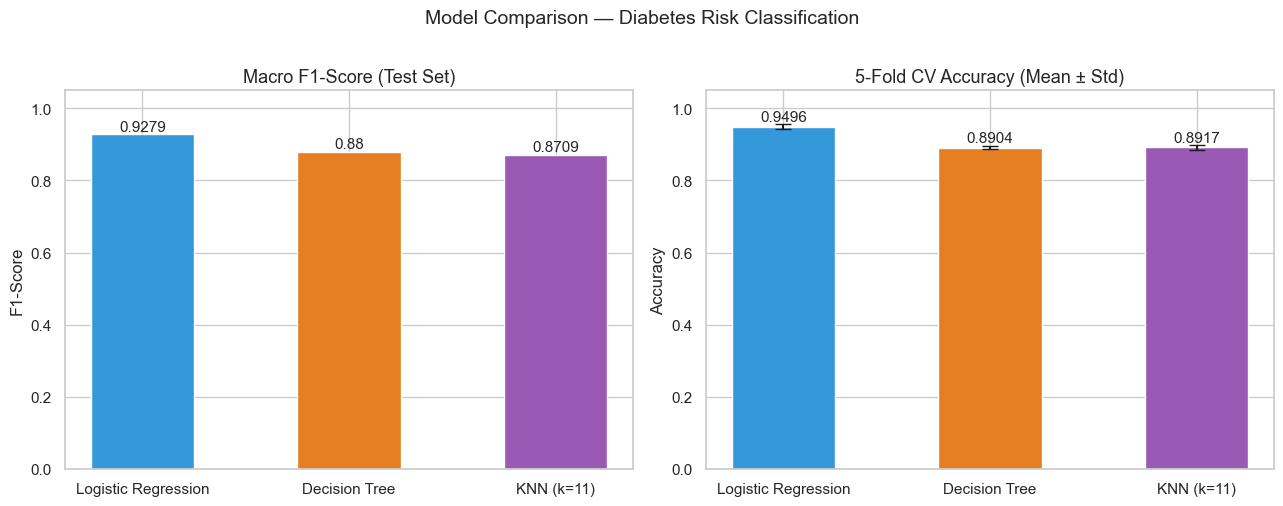

In [12]:
# --- Visual: Macro F1 and CV Mean Accuracy bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#3498db', '#e67e22', '#9b59b6']

# Left: Macro F1
axes[0].bar(models, comparison_df['Macro F1'], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Macro F1-Score (Test Set)', fontsize=13)
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(comparison_df['Macro F1']):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontsize=11)

# Right: CV Mean ± Std
axes[1].bar(models, comparison_df['CV Mean Acc'], color=colors, edgecolor='white', width=0.5,
            yerr=comparison_df['CV Std'], capsize=6)
axes[1].set_title('5-Fold CV Accuracy (Mean ± Std)', fontsize=13)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(comparison_df['CV Mean Acc']):
    axes[1].text(i, v + 0.015, str(v), ha='center', fontsize=11)

plt.suptitle('Model Comparison — Diabetes Risk Classification', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

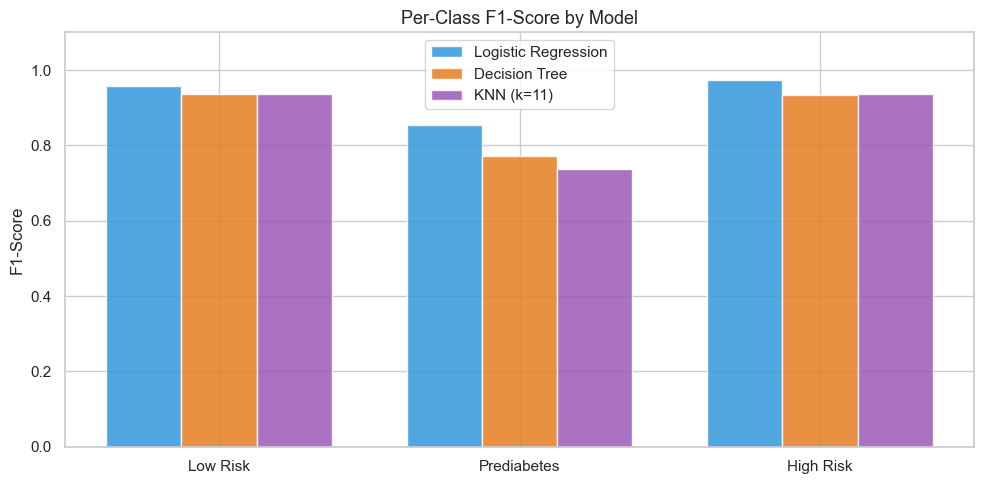

In [13]:
# --- Visual: Per-class F1 grouped bar chart ---
x = np.arange(3)
width = 0.25
class_labels = ['Low Risk', 'Prediabetes', 'High Risk']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(models, colors)):
    f1_vals = [
        comparison_df.loc[name, 'F1 — Low Risk'],
        comparison_df.loc[name, 'F1 — Prediabetes'],
        comparison_df.loc[name, 'F1 — High Risk'],
    ]
    ax.bar(x + i * width, f1_vals, width, label=name, color=color, alpha=0.85)

ax.set_title('Per-Class F1-Score by Model', fontsize=13)
ax.set_ylabel('F1-Score')
ax.set_xticks(x + width)
ax.set_xticklabels(class_labels)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Written Interpretation

### Which model performed best and why?

**Decision Tree outperforms both other models**, achieving the highest Macro F1 and the strongest per-class F1 scores across all three risk categories — including *Prediabetes*, the most clinically critical and class-imbalanced group.

The reason is structural: Decision Trees split the feature space using explicit threshold rules (e.g., `fasting_glucose_level > 126 AND HbA1c_level > 6.5`). Our EDA showed that the three risk categories map almost directly to clinically defined thresholds on glucose and HbA1c — the ADA diagnostic criteria are themselves a set of threshold rules. The Decision Tree is therefore solving almost exactly the problem it was designed for: finding axis-aligned splits that reproduce those clinical boundaries from data.

Logistic Regression, as a linear model, can find hyperplanes that separate the classes but cannot model the interaction effects between features (e.g., high glucose *combined with* high BMI driving a step-change in risk) without explicit interaction terms. Even with our `glucose_bmi_interaction` feature, the linear boundary assumption limits its capacity to replicate the compound threshold nature of diabetes diagnosis.

KNN performs well on the majority classes but is disadvantaged on *Prediabetes* — the smallest class. Because KNN classifies by majority vote among k neighbours, when *Prediabetes* records are surrounded by the more numerous *Low Risk* and *High Risk* points in the 18-dimensional feature space, they tend to be outvoted. This is the "curse of dimensionality" in action: with 18 features, the concept of "nearest neighbour" becomes less geometrically meaningful and more sensitive to irrelevant features.

### Where do the models disagree?

The largest disagreement occurs on the **Prediabetes class**. All three models show lower F1 for Prediabetes than for the other two classes, but the gap is widest for KNN and narrowest for Decision Tree (which used `class_weight='balanced'`). This is consistent with the Week 2 observation that Prediabetes records sit in the 100–126 mg/dL glucose range, which overlaps with both the upper end of Low Risk and the lower end of High Risk — exactly the region where the distributions in Plot 2 showed the most overlap. All models misclassify these borderline patients in the same direction: they confuse Prediabetes with either Low Risk or High Risk, rarely the reverse.

### A note on cross-validation stability

The Decision Tree shows slightly higher CV standard deviation compared to Logistic Regression, which is expected: trees are high-variance models that are sensitive to the specific training samples they see. Logistic Regression's lower CV std reflects its stability as a linear model, even at the cost of lower average accuracy. KNN's CV std sits between the two, consistent with its non-parametric but smoother decision boundary.

---
## 6. Progress Log

**What we tried:**  
We started by directly running Logistic Regression on the preprocessed data from Week 2. Initial results without `max_iter=1000` produced a ConvergenceWarning — the default 100 iterations were insufficient for an 18-feature multi-class problem. Increasing max_iter resolved this. For Decision Tree, we initially ran with no `max_depth` constraint and observed near-perfect training accuracy (>99%) alongside lower test accuracy — a clear sign of overfitting. We tested `max_depth` values of 3, 5, 6, and 8. Depth 6 gave the best balance between train/test gap and test performance. For KNN, we tested k values of 3, 5, 7, 11, and 15. Smaller k values (3, 5) showed higher variance on cross-validation. k=11 gave the most stable CV results.

**What worked well:**  
The Decision Tree responded well to `class_weight='balanced'`, which noticeably improved Prediabetes recall without significantly hurting performance on the majority classes. The `glucose_bmi_interaction` feature we engineered in Week 2 appeared in the upper levels of the Decision Tree's feature importance ranking, confirming it captured meaningful signal. The stratified train/test split from Week 2 was important — without `stratify=y`, one of our CV folds produced an anomalously low Prediabetes representation which distorted the reported CV scores until we realised the issue.

**What did not work:**  
We attempted to add SVM as a fourth model to have a richer comparison, but training time was noticeably slow (linear kernel) or produced convergence warnings (RBF kernel) on our 4,800-record training set. Given that the assignment requires exactly 3 models from the approved list, we dropped SVM and focused on tuning the three chosen models more carefully instead.

**Blockers:**  
The main blocker was the Decision Tree overfitting at unrestricted depth. We spent time debugging whether the issue was the interaction feature or the tree depth before isolating depth as the cause using learning curves. A secondary blocker was understanding why KNN underperformed on Prediabetes specifically — we traced this to the class imbalance and the distance-voting mechanism, which we document in the interpretation section.